# REVISÃO 1º BIMESTRE

**IMPORTAR AS BIBLIOTECAS**

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**IMPORTAR O ARQUIVO .CSV**

In [72]:
df = pd.read_csv("penguins.csv")
df.drop(df.columns[0], axis=1, inplace=True)

**ANALISE OS TIPOS DE DADOS DE CADA COLUNA**

In [73]:
df.head(3)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  310 non-null    float64
 5   body_mass_g        310 non-null    float64
 6   sex                310 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.8+ KB


**QUAIS SÃO AS ESPÉCIES PRESENTES DE PINGUINS?**

In [75]:
df["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

**QUAIS SÃO AS ILHAS PRESENTES?**

In [76]:
df["island"].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [77]:
df["sex"].unique()

array(['MALE', 'FEMALE', nan], dtype=object)

## TIRANDO O .

In [78]:
df[df["sex"] == "."]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex


In [79]:
df.loc[df["sex"] == ".", "sex"] = "FEMALE"

In [80]:
df.to_csv("penguins.csv")

**EXISTEM VALORES FALTANTES EM ALGUMA COLUNA? IDENTIFIQUE QUAIS COLUNAS TÊM DADOS AUSENTES E QUANTIFIQUE-OS.**

In [81]:
df.isna().sum()

species               0
island                0
culmen_length_mm      0
culmen_depth_mm       0
flipper_length_mm    32
body_mass_g          32
sex                  32
dtype: int64

**CALCULE A _MÉDIA_ E A _MEDIANA_ DE `culmen_length_mm` DOS PINGUINS MACHOS E FEMEAS DE CADA ESPÉCIE**

In [82]:
df[(df["species"] == "Adelie") & (df["sex"] == "MALE")]["culmen_length_mm"].mean()

np.float64(40.28955223880598)

In [83]:
df.groupby(["species","sex"])["culmen_length_mm"].mean().reset_index()

,species,sex,culmen_length_mm
0,Adelie,FEMALE,37.264179
1,Adelie,MALE,40.289552
2,Chinstrap,FEMALE,46.700000
3,Chinstrap,MALE,51.094118
4,Gentoo,FEMALE,45.573585
5,Gentoo,MALE,49.412069


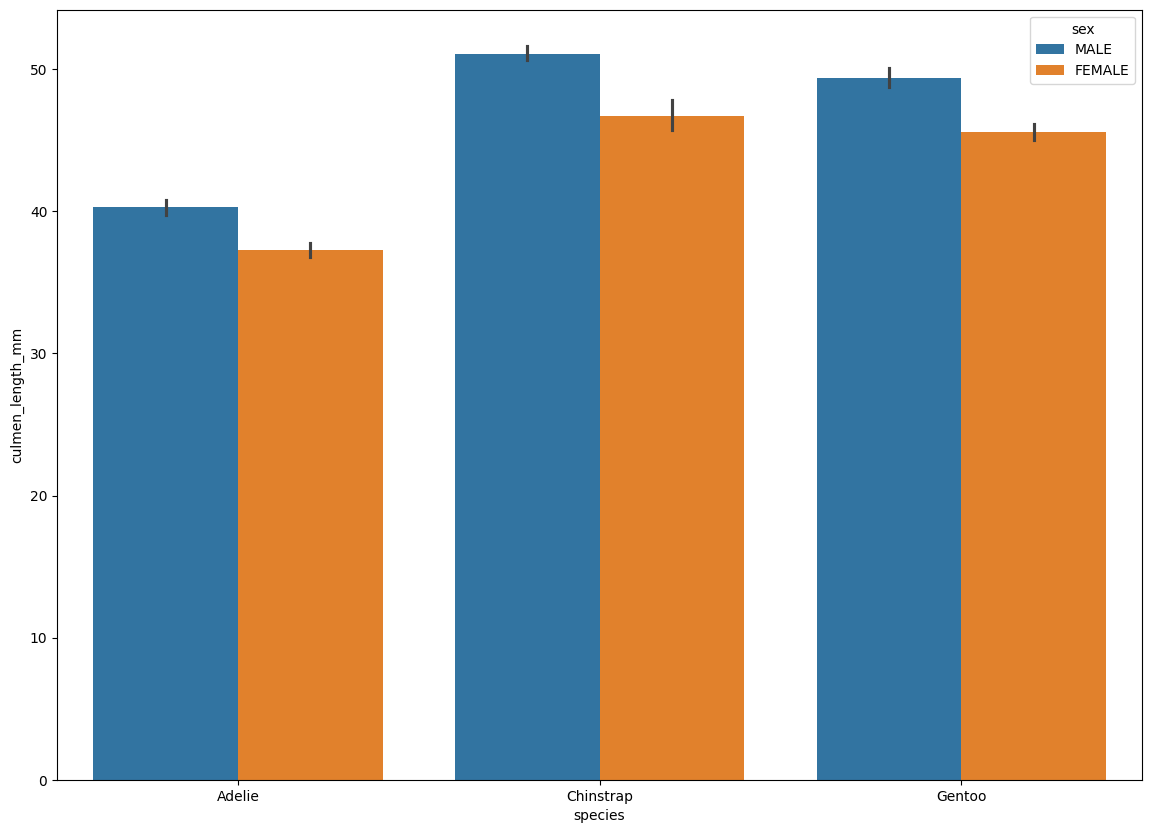

In [84]:
plt.subplots(figsize=(14,10))

sns.barplot(data=df, x = "species", y = "culmen_length_mm",
            hue = "sex")

plt.show()

**PARA CADA _ESPÉCIE_ DE PINGUINS, FAÇA UM _PLOT DE VIOLINO_  DO `culmen_length_mm` DOS PINGUINS MACHOS**

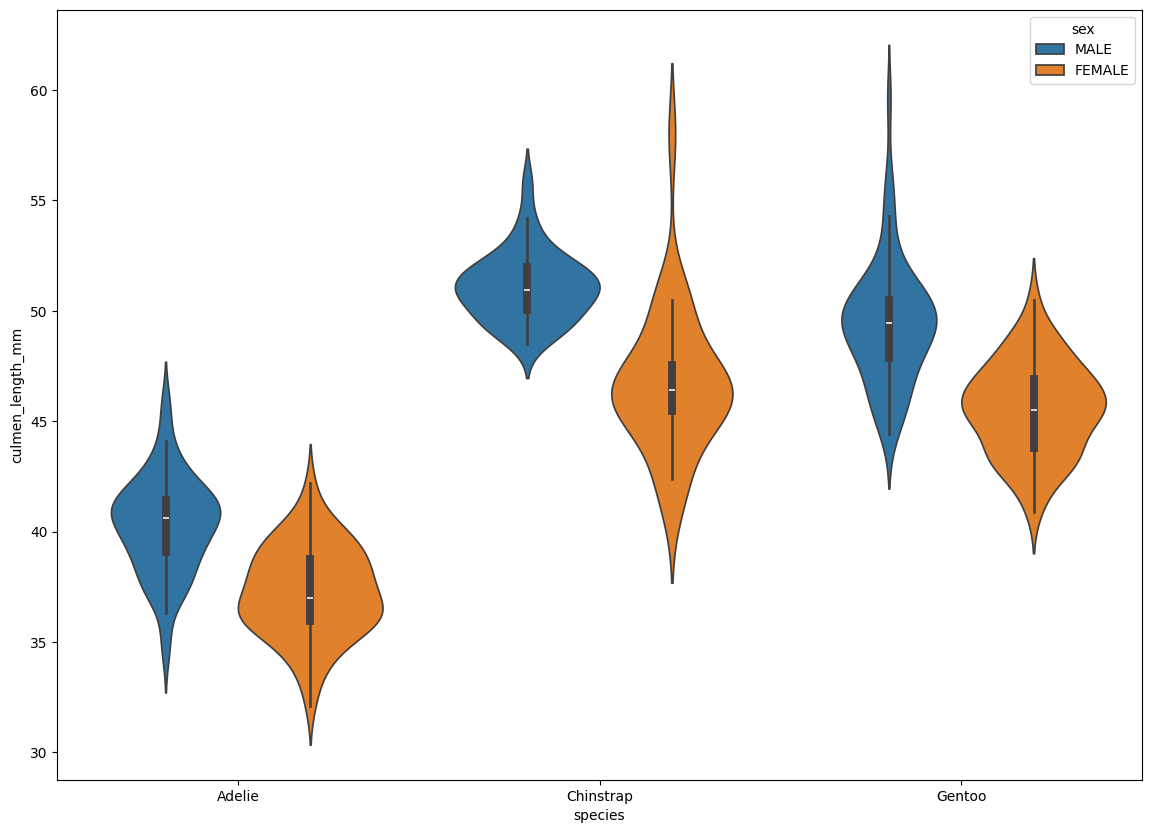

In [85]:
plt.subplots(figsize=(14,10))

sns.violinplot(data=df, x = "species", y = "culmen_length_mm",
            hue = "sex")

plt.show()

In [86]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

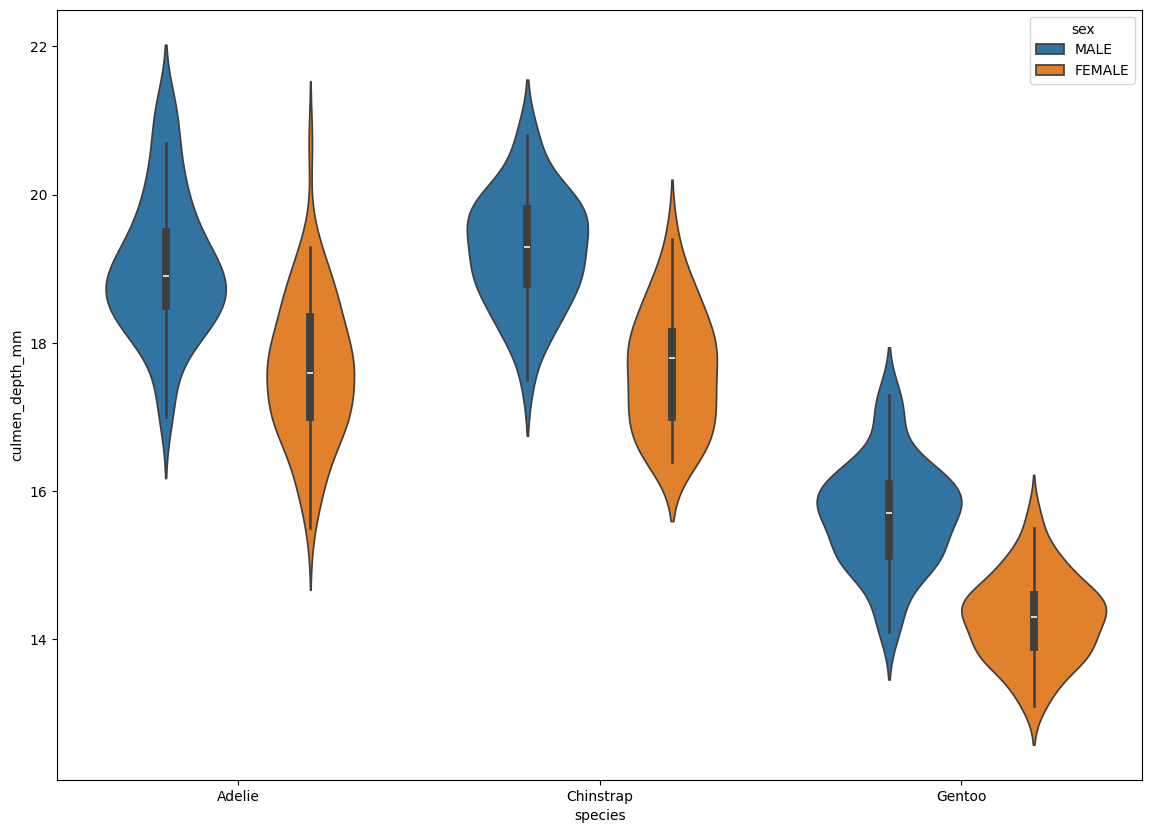

In [87]:
plt.subplots(figsize=(14,10))

sns.violinplot(data=df, x = "species", y = "culmen_depth_mm",
            hue = "sex")

plt.show()

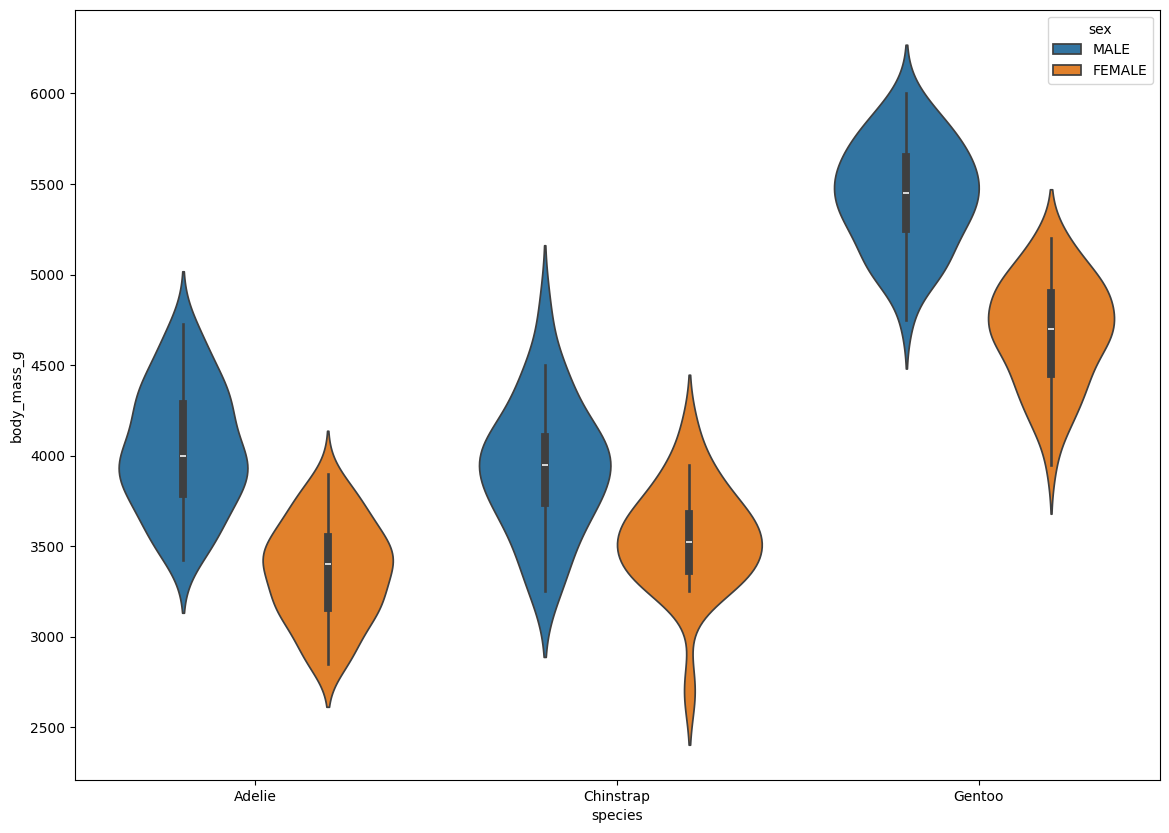

In [88]:
plt.subplots(figsize=(14,10))

sns.violinplot(data=df, x = "species", y = "body_mass_g",
            hue = "sex")

plt.show()

**QUAIS ANÁLISES PODEM SER FEITAS SOBRE OS PINGUINS MACHOS E FÊMEAS?**

`digite aqui sua resposta`

**SUBSTITUA OS VALORES AUSENTES DE ACORDO COM AS SEGUINTES REGRAS**

* **VALORES AUSENTES NA COLUNA `sex`:**
    * **PARA O PINGUI SEM O VALOR, SE O `culmen_length_mm` FOR MAIOR QUE A _MÉDIA_ DAS _MEDIANAS_ DE `culmen_length_mm` DOS GÊNEROS DOS PINGUINS, O PINGUIM É MACHO; CASO CONTRÁRIO, O PINGUIM É FÊMEA.**
    * **ESSA ANÁLISE DEVE SER FEITA PARA OS PINGUINS DE MESMA ESPÉCIE.**

In [89]:
# CÓDIGO #

* **VALORES AUSENTES NA COLUNA `body_mass_g`:**
    * **SUBSTITUA O VALOR DE `body_mass_g` PELA _MÉDIA_ DE `body_mass_g` DOS PINGUINS DO MESMO GÊNERO E ESPÉCIE.**

In [108]:
df.groupby(["species","sex"])["body_mass_g"].mean().reset_index()

,species,sex,body_mass_g
0,Adelie,FEMALE,3362.096774
1,Adelie,MALE,4033.333333
2,Chinstrap,FEMALE,3538.461538
3,Chinstrap,MALE,3931.451613
4,Gentoo,FEMALE,4685.714286
5,Gentoo,MALE,5436.224490


In [116]:
df[(df["species"] == "Adelie") & (df["sex"] == "MALE")].isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [117]:
df[(df["species"] == "Adelie") & (df["sex"] == "MALE")] = df[(df["species"] == "Adelie") & (df["sex"] == "MALE")].fillna(4033.333333, inplace=True)

/tmp/ipykernel_204233/4205810773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[(df["species"] == "Adelie") & (df["sex"] == "MALE")] = df[(df["species"] == "Adelie") & (df["sex"] == "MALE")].fillna(4033.333333, inplace=True)


**FAÇA UM HISTOGRAMA PARA MOSTRAR A QUANTIDADE DE PINGUINS DE CADA ILHA.**

In [91]:
# CÓDIGO #

**CONSTRUA UM GRÁFICO DE DISPERSÃO QUE RELACIONE `culmen_length_mm` E `culmen_depth_mm` COM AS CORES REPRESENTANDO AS ESPÉCIES.**

In [106]:
df["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

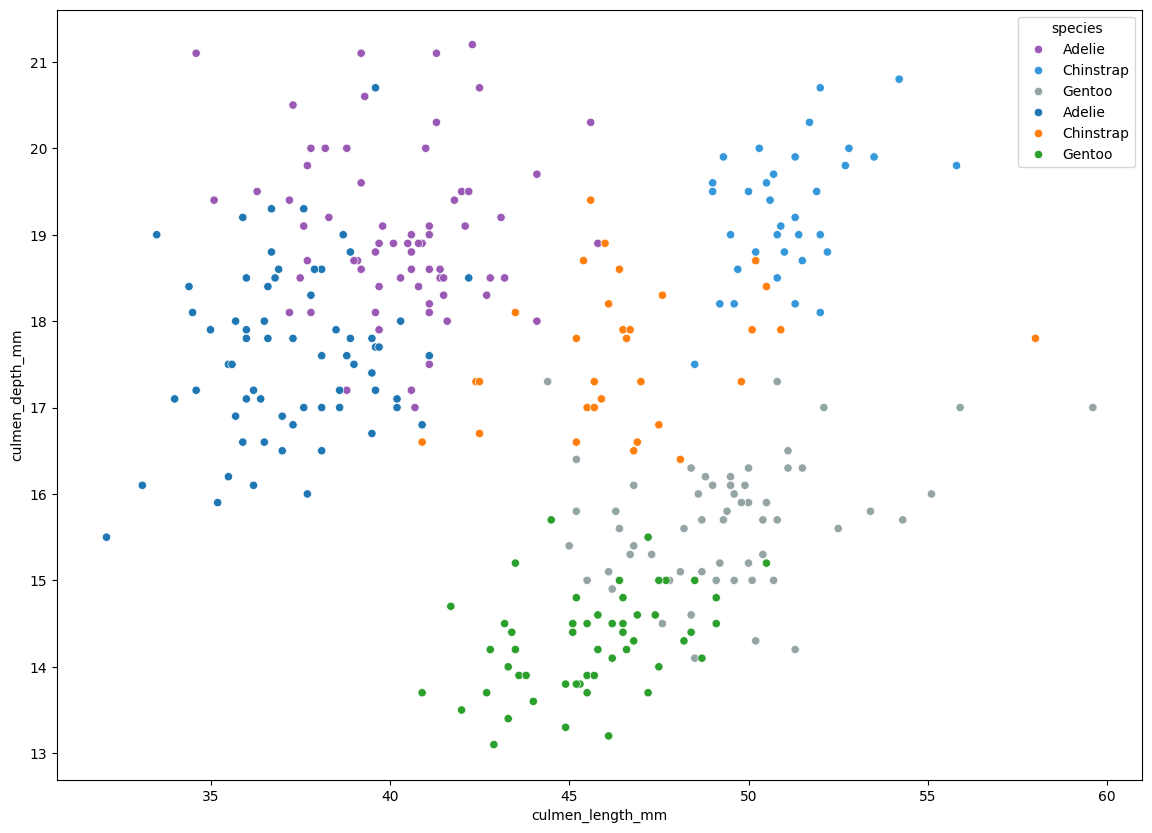

In [107]:
plt.subplots(figsize = (14,10))

sns.scatterplot(data=df[df["sex"] == "MALE"], x = "culmen_length_mm", y = "culmen_depth_mm", hue = "species", palette=dict(Adelie="#9b59b6", Chinstrap="#3498db", Gentoo="#95a5a6"))
sns.scatterplot(data=df[df["sex"] == "FEMALE"], x = "culmen_length_mm", y = "culmen_depth_mm", hue = "species")


plt.show()

**QUAIS ANÁLISES PODEM SER FEITAS A PARTIR DO GRÁFICO DE DISPERSÃO?**

`digite aqui sua resposta`

**CONSIDERE A SITUAÇÃO DE ESCOLHER UM PINGUIM ALEATÓRIO E RESPONDA AS SEGUINTES PERGUNTAS:**
* **QUAL É A PROBABILIDADE DO PINGUIM SER DA ILHA `Torgersen`?**

In [93]:
# CÓDIGO #

* **DADO A SITUAÇÃO DE O PINGUIM SER MACHO, QUAL É A PROBABILIDADE DE ELE SER DA ESPÉCIE `Gentoo`?**

In [94]:
# CÓDIGO #

* **DADA A SITUAÇÃO DE O PINGUIM SER FÊMEA E DA ESPÉCIE `Chinstrap`, QUAL É A PROBABILIDADE DE O TAMANHO DE `culmen_length_mm` SER MENOR QUE 33mm?**

In [95]:
# CÓDIGO #

* **DESENVOLVA UM CÓDIGO QUE CALCULE A PROBABILIDADE EXPERIMENTAL DE ENCONTRAR UM PINGUIM MACHO DA ILHA `Dream`**

In [96]:
# CÓDIGO #